# Ensemble

We combine all the topic models to create an ensemble representation of the narrative structure.

## Combine Topic Models

In [332]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# This is to align the topic model numbers
# The lists were discovered by comparing topic glosses (see below)
def fix_cols(df):
    if src_id == 'ximenez':
        df = df[[0,1,3,2,4,5]]
    elif src_id == 'christenson_ximenez':
        df =  df[[0,1,3,2,5,4]]
    df.columns = [0,1,2,3,4,5]
    return df

# Combine all the topic models
src_ids = "ajtzibab christenson colop christenson_ximenez ximenez".split()
theta_list = []
topic_list = []
for src_id in src_ids:
    theta = pd.read_csv(f"../{src_id}/{src_id}-THETA.csv").set_index('doc_id')
    theta.columns = [0,1,2,3,4,5] # Convert col names to ints
    theta = fix_cols(theta)
    theta_list.append(theta)
    topic = pd.read_csv(f"../{src_id}/{src_id}-TOPIC.csv").set_index('topic_id')
    topic = fix_cols(topic.T).T
    topic_list.append(topic)
THETA = pd.concat(theta_list, keys = src_ids).groupby('doc_id').mean()
TOPIC = pd.concat(topic_list, keys = src_ids)

# Compare topic glosses to see if topics align
TOPIC.gloss.unstack()

,0,1,2,3,4,5
ajtzibab,xib'alb'a,tojil,ajpop,kaj,sipakna,kati't
christenson,xib'alb'a,b'alam,pop,b'it,sipakna,kati't
colop,kame,b'alam,ajaw,kaj,sipakna,kati't
christenson_ximenez,xibalba,balam,ahpop,cah,caquix,catit
ximenez,xibalba,balam,ahpop,cah,zipacna,catit


## Visualize Ensemble Topics over Time

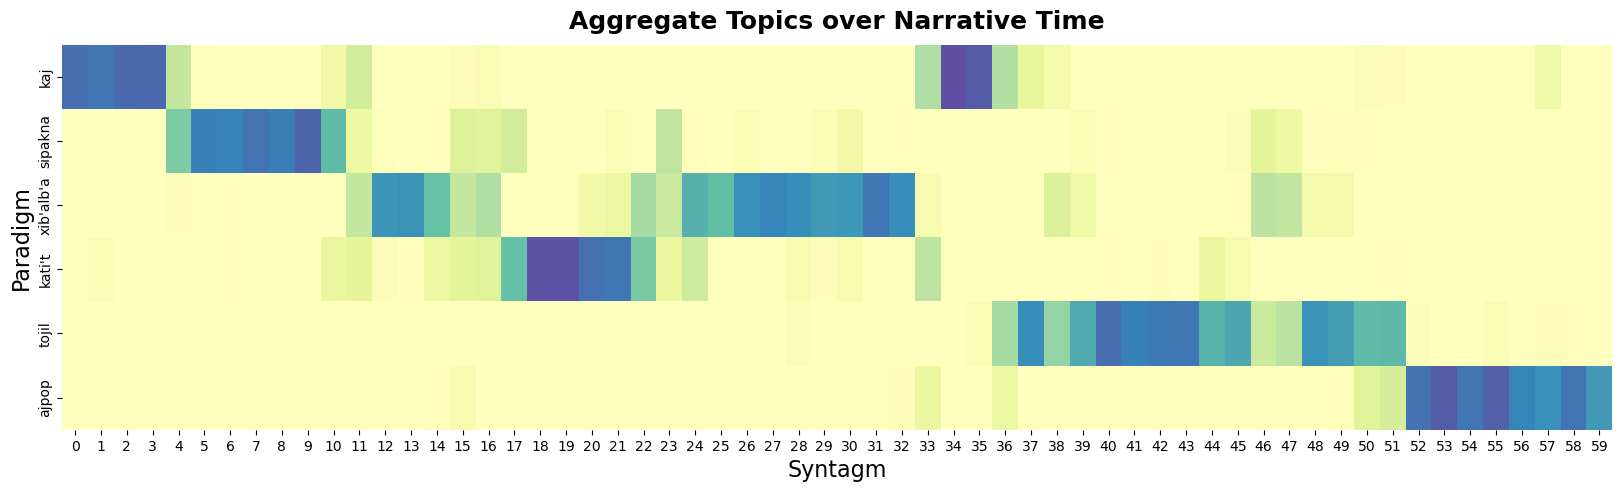

In [333]:
# Set the display order of the topics
new_order= [3,4,0,5,1,2]

# Replace topic numbers with glosses in the display
glosses = TOPIC.loc['ajtzibab'].loc[new_order].gloss
fig, ax = plt.subplots(figsize=(20,5))
sns.heatmap(
    THETA.T.loc[new_order].set_index(glosses), 
    cmap='Spectral', 
    center=0,
    cbar=None
)
plt.title(f"Aggregate Topics over Narrative Time", fontsize=18, fontweight='bold', y=1.02)
ax.set_xlabel("Chunk Number", fontsize=10)
ax.set_ylabel("Topic", fontsize=10)
plt.savefig(f"ensemble-topic-over-doc.svg", bbox_inches='tight')
plt.savefig(f"ensemble-topic-over-doc.png", bbox_inches='tight')
plt.xlabel("Syntagm", fontsize=16)
plt.ylabel("Paradigm", fontsize=16)
plt.show()